In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 170M/170M [19:39<00:00, 145kB/s]


Training samples: 50000
Testing samples: 10000


In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 782
Testing batches: 157


In [4]:
import matplotlib.pyplot as plt

classes = (
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nFirst 8 labels:")
print([classes[label] for label in labels[:8]])

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])

First 8 labels:
['automobile', 'automobile', 'cat', 'cat', 'deer', 'cat', 'ship', 'ship']


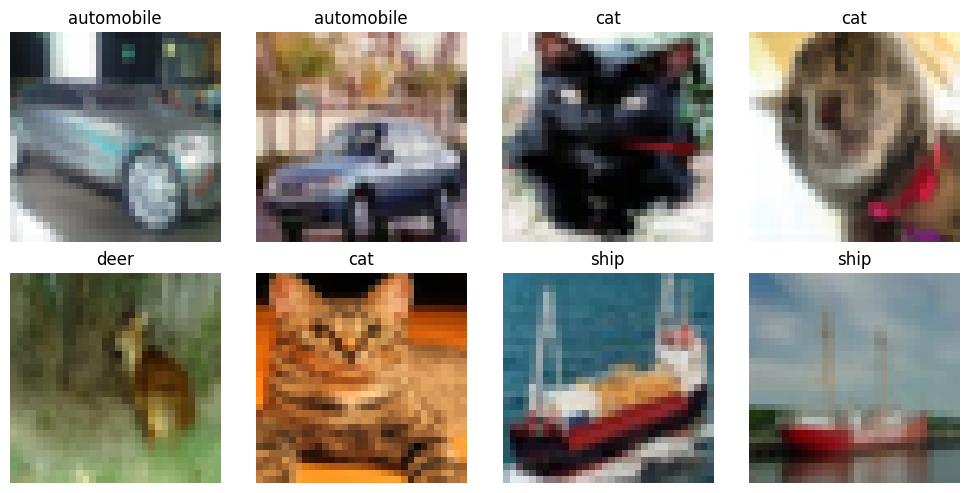

In [5]:
# Display a few sample images

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


model = CNN()

print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [8]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {average_loss:.4f}")

Epoch [1/5], Loss: 1.3554
Epoch [2/5], Loss: 0.9732
Epoch [3/5], Loss: 0.8112
Epoch [4/5], Loss: 0.6952
Epoch [5/5], Loss: 0.5953


In [9]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 72.22%


In [10]:
id="n6u2vr"
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

print("Actual labels:")
print([classes[label] for label in labels[:8]])

print("\nPredicted labels:")
print([classes[label] for label in predicted[:8]])

Actual labels:
['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']

Predicted labels:
['cat', 'ship', 'airplane', 'airplane', 'frog', 'frog', 'automobile', 'frog']


## Results and Conclusion

A Convolutional Neural Network (CNN) was implemented using PyTorch for
image classification on the CIFAR-10 dataset.

### Results
- Dataset: CIFAR-10
- Training Images: 50,000
- Testing Images: 10,000
- Image Size: 32 × 32 RGB
- Number of Classes: 10
- Epochs: 5
- Final Training Loss: 0.5953
- Test Accuracy: 72.22%

The CNN successfully learned image features and classified images into
the 10 CIFAR-10 categories. The model achieved a test accuracy of
72.22% after 5 epochs.

Sample predictions were also checked to compare the actual and predicted
classes. Some images were classified correctly while a few were
misclassified, showing that the model can still be improved through
hyperparameter tuning and further training.